# Naive Bayes: Jednoduchý, rychlý a efektivní klasifikátor

## Co je Naive Bayes?

Naive Bayes je rodina pravděpodobnostních klasifikátorů založených na Bayesově teorému s předpokladem nezávislosti mezi příznaky (odtud označení "naive" - naivní). Navzdory tomuto zjednodušujícímu předpokladu, který v reálném světě často není splněn, tyto klasifikátory fungují překvapivě dobře v mnoha praktických situacích.

### Jak Naive Bayes funguje:

Naive Bayes klasifikátor aplikuje Bayesův teorém s "naivním" předpokladem nezávislosti:

$$P(y|x_1, x_2, ..., x_n) = \frac{P(y) \cdot P(x_1, x_2, ..., x_n|y)}{P(x_1, x_2, ..., x_n)}$$

Díky předpokladu nezávislosti můžeme zjednodušit:

$$P(y|x_1, x_2, ..., x_n) \propto P(y) \prod_{i=1}^{n} P(x_i|y)$$

### Hlavní typy Naive Bayes klasifikátorů v scikit-learn:

1. **GaussianNB** - předpokládá, že příznaky sledují normální rozdělení; vhodný pro spojité hodnoty
2. **MultinomialNB** - vhodný pro diskrétní hodnoty (např. počet výskytů slov); často používán v textové klasifikaci
3. **BernoulliNB** - specializován na binární/boolean příznaky
4. **ComplementNB** - adaptace MultinomialNB pro nevyvážené datasety
5. **CategoricalNB** - pro kategorické příznaky

### Kdy použít Naive Bayes:

- Pro klasifikaci textů a zpracování přirozeného jazyka (NLP)
- Pro filtrování spamu
- Pro rychlou klasifikaci s malým množstvím trénovacích dat
- Když potřebujete rychlý model s nízkou výpočetní náročností
- Pro multiclass klasifikační problémy
- Jako základní model pro porovnání s komplexnějšími přístupy

### Výhody:

- Jednoduchý a rychlý na trénování i predikci
- Funguje dobře s vysokodimenzionálními daty
- Efektivní pro malé trénovací datasety
- Nenáchylný k přeučení
- Poskytuje pravděpodobnostní předpovědi
- Funguje dobře i když předpoklad nezávislosti není zcela splněn

### Nevýhody:

- Předpoklad nezávislosti příznaků je často nerealistický
- Limitovaná modelovací síla (může být příliš jednoduchý pro komplexní vztahy)
- Problémy s příznaky, které se nevyskytují v trénovacích datech ("zero frequency problem")
- Nepřesné odhady pravděpodobností (i když relativní pořadí bývá správné)

Pojďme si nyní implementovat a vyzkoušet různé typy Naive Bayes klasifikátorů na reálných datech.

In [1]:
# Import základních knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Import pro zpracování dat a evaluaci modelů
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    roc_curve, roc_auc_score, precision_recall_curve
)

# Import Naive Bayes klasifikátorů
from sklearn.naive_bayes import (
    GaussianNB, MultinomialNB, BernoulliNB, ComplementNB, CategoricalNB
)

# Import datasetů
from sklearn.datasets import load_breast_cancer, fetch_20newsgroups

# Konfigurace vizualizací
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('viridis')

# Pro reprodukovatelnost
np.random.seed(42)

## 1. Implementace GaussianNB na datasetu rakoviny prsu

Začneme s GaussianNB, který je vhodný pro spojité příznaky. Použijeme dataset rakoviny prsu ze scikit-learn, který obsahuje různé metriky extrahované z digitálních snímků jader buněk prsní tkáně.

In [2]:
# Načtení datasetu rakoviny prsu
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Základní informace o datasetu
print(f"Tvar datasetu: {X.shape}")
print(f"Příznaky: {cancer.feature_names[:5]}... (celkem {len(cancer.feature_names)})")
print(f"Třídy: {cancer.target_names}")
print(f"Rozložení tříd: {np.bincount(y)}")

# Rozdělení dat na trénovací a testovací množinu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Vytvoření a trénování modelu GaussianNB
gnb = GaussianNB()
start_time = time()
gnb.fit(X_train, y_train)
train_time = time() - start_time

# Predikce na testovacích datech
start_time = time()
y_pred = gnb.predict(X_test)
predict_time = time() - start_time

# Vyhodnocení modelu
accuracy = accuracy_score(y_test, y_pred)
print(f"\nGaussianNB - výsledky:")
print(f"Přesnost: {accuracy:.4f}")
print(f"Čas trénování: {train_time:.4f} s")
print(f"Čas predikce: {predict_time:.4f} s")
print("\nKlasifikační report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Tvar datasetu: (569, 30)
Příznaky: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']... (celkem 30)
Třídy: ['malignant' 'benign']
Rozložení tříd: [212 357]

GaussianNB - výsledky:
Přesnost: 0.9371
Čas trénování: 0.0035 s
Čas predikce: 0.0010 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143



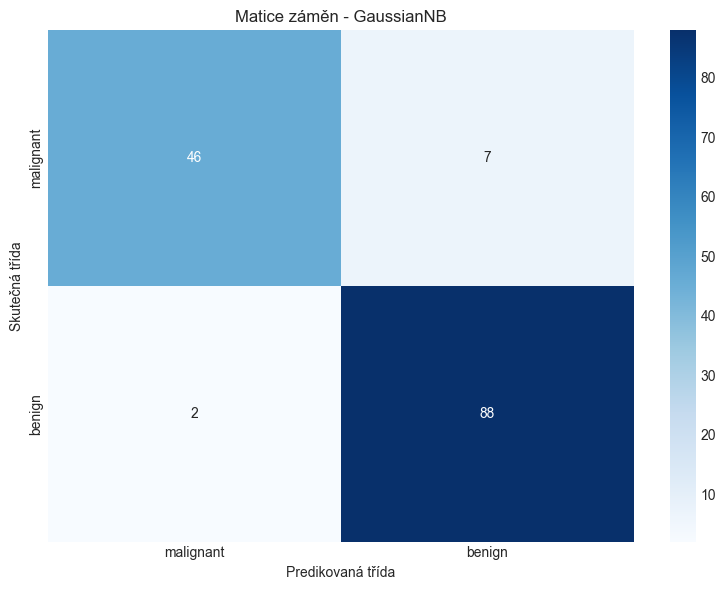

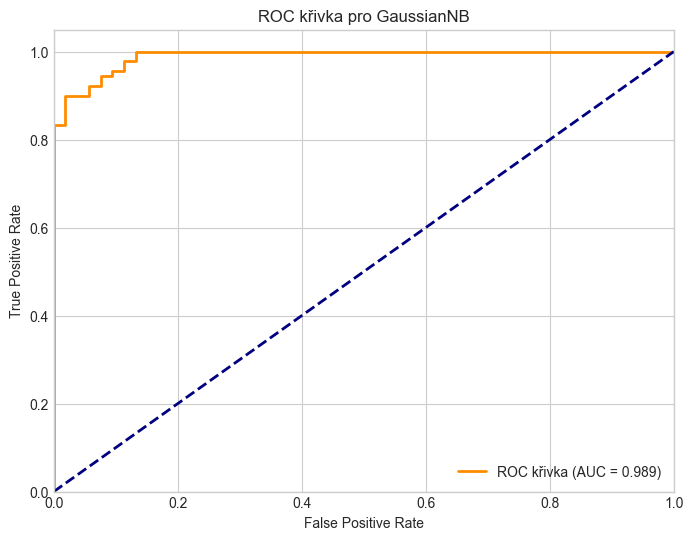

In [3]:
# Vizualizace matice záměn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predikovaná třída')
plt.ylabel('Skutečná třída')
plt.title('Matice záměn - GaussianNB')
plt.tight_layout()
plt.show()

# Vizualizace ROC křivky
y_prob = gnb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC křivka (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC křivka pro GaussianNB')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Analýza pravděpodobností a prior distribucí v GaussianNB

Jednou z výhod Naive Bayes je jeho interpretovatelnost. Podívejme se na prior pravděpodobnosti (počáteční pravděpodobnosti tříd) a na to, jak model hodnotí jednotlivé příznaky.

Prior pravděpodobnosti tříd:
malignant: 0.3732
benign: 0.6268


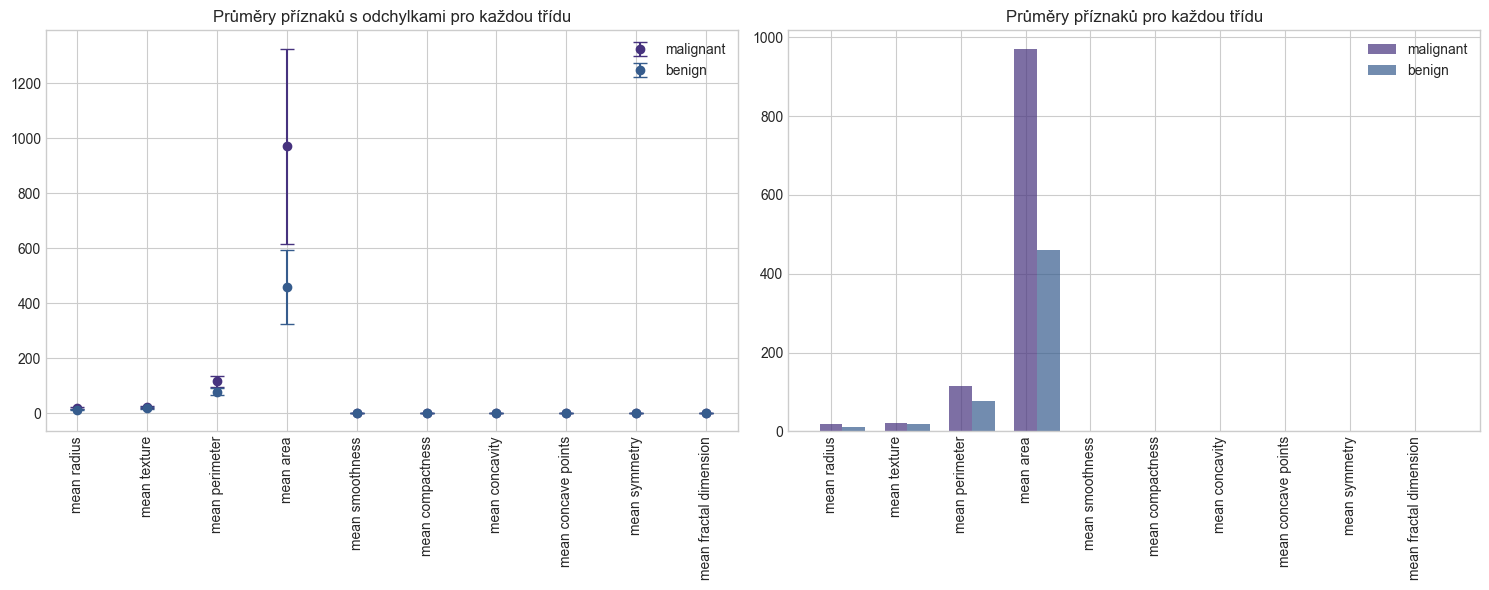

In [4]:
# Prior pravděpodobnosti tříd
print("Prior pravděpodobnosti tříd:")
for i, class_name in enumerate(cancer.target_names):
    print(f"{class_name}: {gnb.class_prior_[i]:.4f}")

# Vizualizace průměrů a standardních odchylek příznaků pro každou třídu
# Pro ukázku použijeme jen prvních 10 příznaků, aby byl graf přehledný
n_features = 10
feature_names = cancer.feature_names[:n_features]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for i, class_name in enumerate(cancer.target_names):
    plt.errorbar(feature_names, gnb.theta_[i, :n_features], 
                 yerr=np.sqrt(gnb.var_[i, :n_features]), 
                 fmt='o', capsize=5, label=class_name)
plt.xticks(rotation=90)
plt.title('Průměry příznaků s odchylkami pro každou třídu')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for i, class_name in enumerate(cancer.target_names):
    plt.bar(np.arange(n_features) + i*0.35, gnb.theta_[i, :n_features], 
            width=0.35, alpha=0.7, label=class_name)
plt.xticks(np.arange(n_features), feature_names, rotation=90)
plt.title('Průměry příznaků pro každou třídu')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 2. Implementace MultinomialNB pro textová data

Nyní implementujeme MultinomialNB, který je ideální pro diskrétní příznaky jako jsou počty slov v textovém dokumentu. Použijeme dataset 20 Newsgroups, který obsahuje texty z různých diskuzních skupin.

In [5]:
# Pro jednoduchost použijeme podmnožinu 4 kategorií z 20 Newsgroups datasetu
categories = [
    'sci.electronics',
    'rec.sport.baseball',
    'talk.politics.guns',
    'comp.graphics'
]

# Načtení dat
print("Načítám textová data...")
news_train = fetch_20newsgroups(subset='train', categories=categories, random_state=42,
                               remove=('headers', 'footers', 'quotes'))
news_test = fetch_20newsgroups(subset='test', categories=categories, random_state=42,
                              remove=('headers', 'footers', 'quotes'))

# Základní informace o datasetu
print(f"Počet trénovacích dokumentů: {len(news_train.data)}")
print(f"Počet testovacích dokumentů: {len(news_test.data)}")
print(f"Kategorie: {news_train.target_names}")

# Podíváme se na rozložení tříd
unique, counts = np.unique(news_train.target, return_counts=True)
for i, (cat, count) in enumerate(zip(categories, counts)):
    print(f"{cat}: {count} dokumentů")

# Ukázka dokumentu
print("\nUkázka dokumentu:")
print(f"Kategorie: {news_train.target_names[news_train.target[0]]}")
print(news_train.data[0][:300] + "...")

Načítám textová data...
Počet trénovacích dokumentů: 2318
Počet testovacích dokumentů: 1543
Kategorie: ['comp.graphics', 'rec.sport.baseball', 'sci.electronics', 'talk.politics.guns']
sci.electronics: 584 dokumentů
rec.sport.baseball: 597 dokumentů
talk.politics.guns: 591 dokumentů
comp.graphics: 546 dokumentů

Ukázka dokumentu:
Kategorie: rec.sport.baseball
The Angels won their home opener against the Brewers today before 33,000+ 
at Anaheim Stadium, 3-1 on a 3-hitter by Mark Langston.  J.T. Snow and 
Gary Discarcina hit home runs for the Angels....


In [6]:
# Vytvoření pipeline pro zpracování textu a klasifikaci
text_clf = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=5)),
    ('clf', MultinomialNB(alpha=0.01))
])

# Trénování modelu
start_time = time()
text_clf.fit(news_train.data, news_train.target)
train_time = time() - start_time

# Predikce na testovacích datech
start_time = time()
y_pred = text_clf.predict(news_test.data)
predict_time = time() - start_time

# Vyhodnocení
accuracy = accuracy_score(news_test.target, y_pred)
print(f"\nMultinomialNB pro text - výsledky:")
print(f"Přesnost: {accuracy:.4f}")
print(f"Čas trénování: {train_time:.4f} s")
print(f"Čas predikce: {predict_time:.4f} s")
print("\nKlasifikační report:")
print(classification_report(news_test.target, y_pred, target_names=categories))


MultinomialNB pro text - výsledky:
Přesnost: 0.8658
Čas trénování: 0.3862 s
Čas predikce: 0.1616 s

Klasifikační report:
                    precision    recall  f1-score   support

   sci.electronics       0.81      0.89      0.85       389
rec.sport.baseball       0.89      0.90      0.90       397
talk.politics.guns       0.89      0.75      0.81       393
     comp.graphics       0.88      0.92      0.90       364

          accuracy                           0.87      1543
         macro avg       0.87      0.87      0.87      1543
      weighted avg       0.87      0.87      0.86      1543



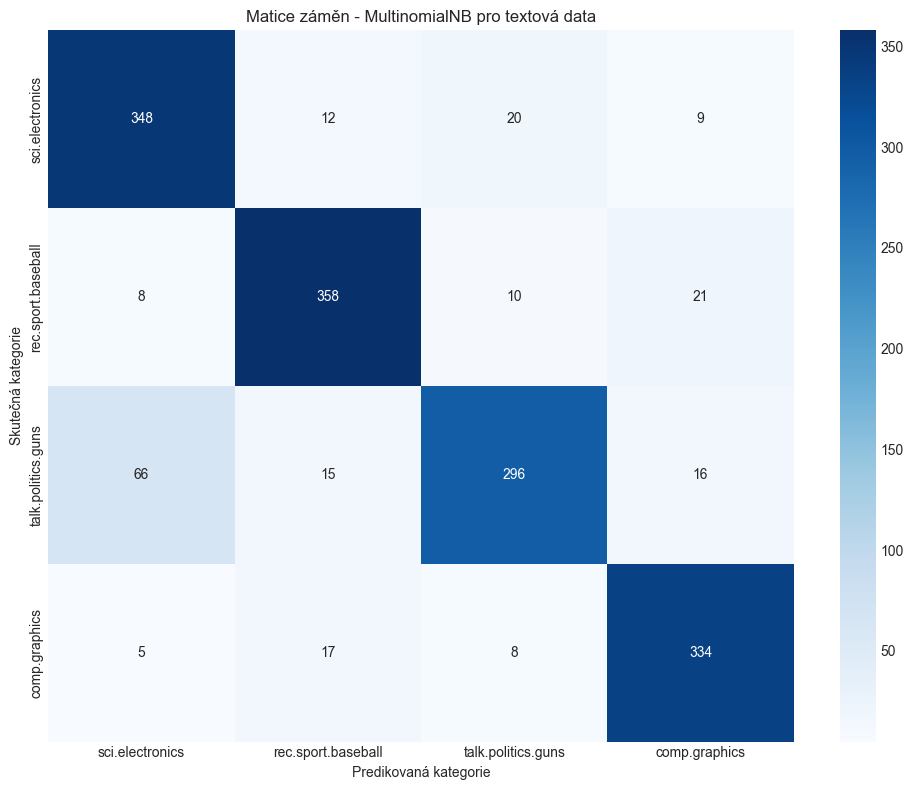

In [7]:
# Vizualizace matice záměn
cm = confusion_matrix(news_test.target, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel('Predikovaná kategorie')
plt.ylabel('Skutečná kategorie')
plt.title('Matice záměn - MultinomialNB pro textová data')
plt.tight_layout()
plt.show()

### Analýza významných slov pro každou kategorii

Podíváme se na nejdůležitější slova pro každou kategorii podle MultinomialNB modelu.

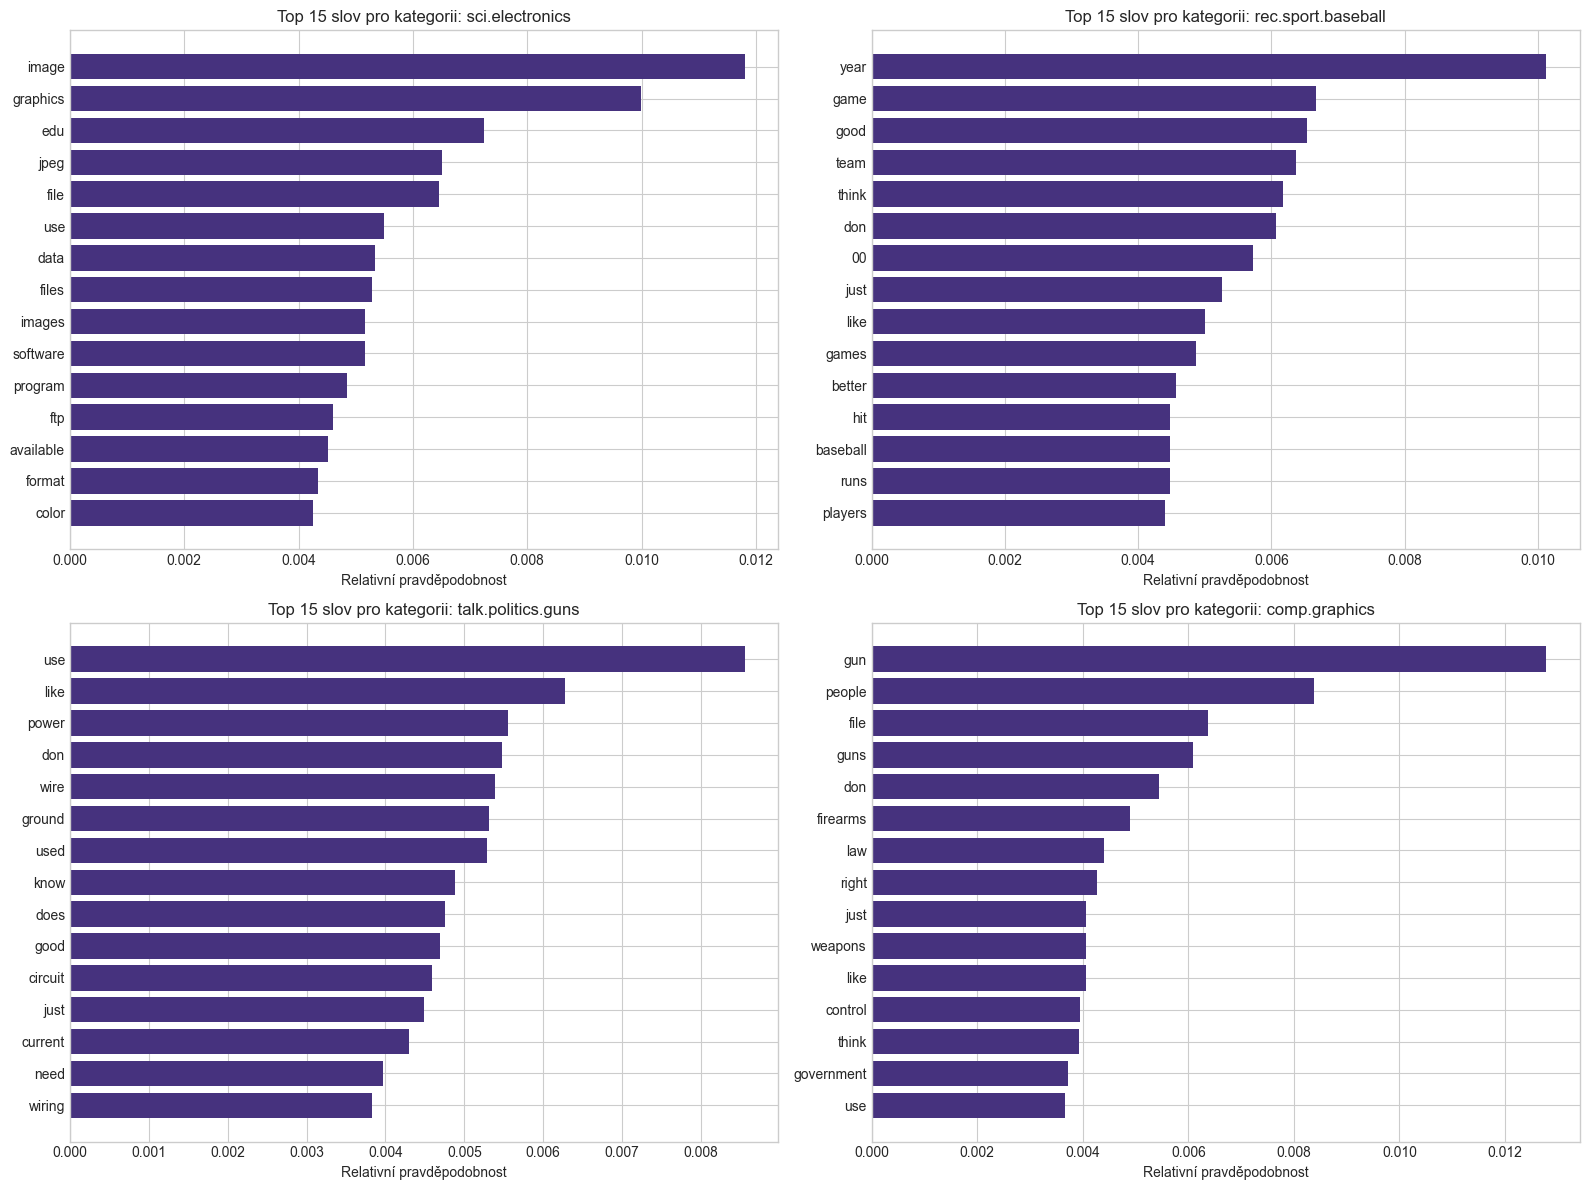

In [8]:
# Získání významných slov pro každou kategorii
vectorizer = text_clf.named_steps['vect']
nb = text_clf.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

def get_top_words(classifier, feature_names, top_n=15):
    """Získá top slova pro každou třídu podle jejich log pravděpodobnosti"""
    top_words_per_class = {}
    
    for i, category in enumerate(categories):
        # Log pravděpodobnosti slov pro danou třídu
        log_probs = classifier.feature_log_prob_[i]
        # Seřazení podle log pravděpodobnosti
        top_indices = np.argsort(log_probs)[::-1][:top_n]
        top_words = [(feature_names[j], np.exp(log_probs[j])) for j in top_indices]
        top_words_per_class[category] = top_words
    
    return top_words_per_class

# Získání top slov pro každou kategorii
top_words = get_top_words(nb, feature_names)

# Vizualizace top slov pro každou kategorii
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (category, words) in enumerate(top_words.items()):
    words, probs = zip(*words)
    ax = axes[i]
    y_pos = np.arange(len(words))
    ax.barh(y_pos, probs, align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()  # Nejdůležitější slova nahoře
    ax.set_title(f'Top 15 slov pro kategorii: {category}')
    ax.set_xlabel('Relativní pravděpodobnost')

plt.tight_layout()
plt.show()

## 3. Porovnání různých typů Naive Bayes klasifikátorů

Nyní porovnáme výkon různých typů Naive Bayes klasifikátorů na datasetu rakoviny prsu.

In [9]:
# Definice klasifikátorů k porovnání
classifiers = [
    ('GaussianNB', GaussianNB()),
    ('MultinomialNB', MultinomialNB()),  # Pracuje s nezápornými hodnotami
    ('BernoulliNB', BernoulliNB()),
    ('ComplementNB', ComplementNB())      # Také pro nezáporné hodnoty
    # CategoricalNB vynecháváme, protože potřebuje kategorické příznaky
]

# Ujistíme se, že data jsou nezáporná pro MultinomialNB a ComplementNB
# Použijeme MinMaxScaler místo StandardScaler, aby data byla v rozmezí [0,1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Porovnání klasifikátorů
results = []

for name, clf in classifiers:
    # Trénování
    start_time = time()
    clf.fit(X_train_scaled, y_train)
    train_time = time() - start_time
    
    # Predikce
    start_time = time()
    y_pred = clf.predict(X_test_scaled)
    predict_time = time() - start_time
    
    # Metriky
    accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validace
    cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Uložení výsledků
    results.append({
        'name': name,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time': predict_time,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    })
    
    # Výpis výsledků
    print(f"\n{name}:")
    print(f"Přesnost: {accuracy:.4f}")
    print(f"Cross-validace: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Čas trénování: {train_time:.4f} s")
    print(f"Čas predikce: {predict_time:.4f} s")
    print("\nKlasifikační report:")
    print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# Vytvoření přehledné tabulky výsledků
results_df = pd.DataFrame(results)
print("\nSouhrnné výsledky:")
print(results_df[['name', 'accuracy', 'cv_mean', 'cv_std', 'train_time', 'predict_time']])


GaussianNB:
Přesnost: 0.9371
Cross-validace: 0.9319 ± 0.0117
Čas trénování: 0.0030 s
Čas predikce: 0.0010 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.94      0.89      0.91        53
      benign       0.94      0.97      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143


MultinomialNB:
Přesnost: 0.8531
Cross-validace: 0.8427 ± 0.0125
Čas trénování: 0.0020 s
Čas predikce: 0.0000 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       1.00      0.60      0.75        53
      benign       0.81      1.00      0.90        90

    accuracy                           0.85       143
   macro avg       0.91      0.80      0.82       143
weighted avg       0.88      0.85      0.84       143


BernoulliNB:
Přesnost: 0.6294
Cross-validace: 0.6173 ± 0.0147
Čas trénování: 0.0

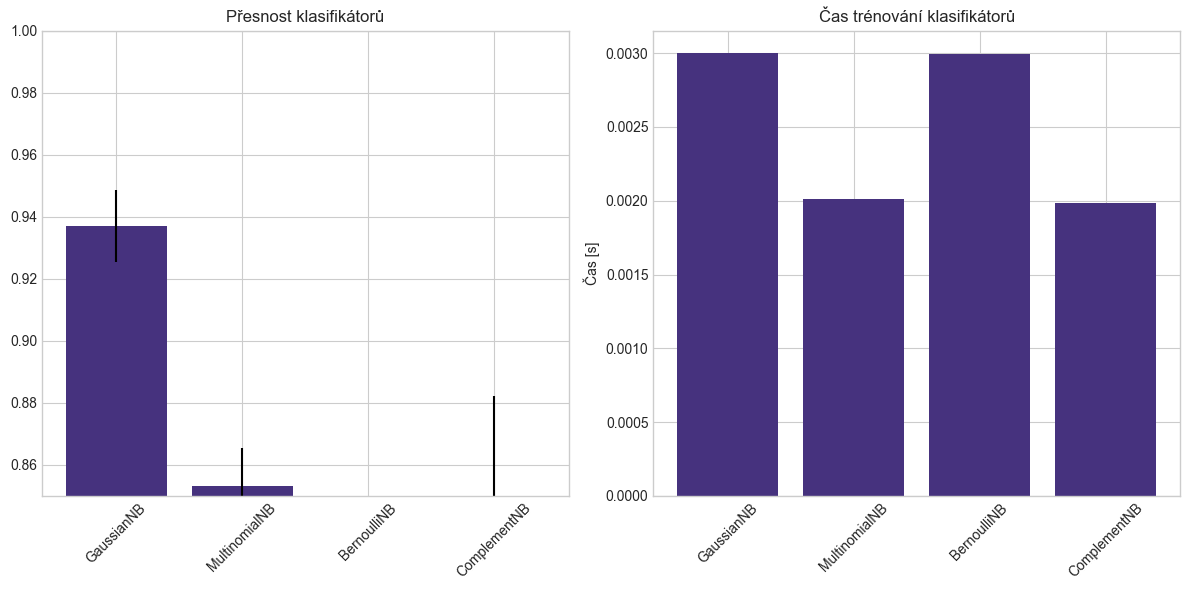

In [10]:
# Vizualizace porovnání klasifikátorů
plt.figure(figsize=(12, 6))

# Přesnost
plt.subplot(1, 2, 1)
plt.bar(results_df['name'], results_df['accuracy'], yerr=results_df['cv_std'])
plt.ylim([0.85, 1.0])
plt.title('Přesnost klasifikátorů')
plt.xticks(rotation=45)
plt.grid(True, axis='y')

# Čas trénování
plt.subplot(1, 2, 2)
plt.bar(results_df['name'], results_df['train_time'])
plt.title('Čas trénování klasifikátorů')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.ylabel('Čas [s]')

plt.tight_layout()
plt.show()

## 4. Optimalizace hyperparametrů pro MultinomialNB na textových datech

MultinomialNB má hyperparametr `alpha` (Laplaceova vyhlazovací konstanta), který může mít významný vliv na výkon modelu. Zkusme najít optimální hodnotu pomocí GridSearchCV.

In [11]:
# Vytvoření pipeline pro optimalizaci
pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('clf', MultinomialNB())
])

# Parametry pro GridSearch
parameters = {
    'vect__min_df': [3, 5, 10],
    'vect__ngram_range': [(1, 1), (1, 2)],  # unigrams or bigrams
    'clf__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
}

# GridSearch s cross-validací
grid_search = GridSearchCV(pipeline, parameters, cv=5, n_jobs=-1, verbose=1)
print("Spouštím GridSearchCV...")
grid_search.fit(news_train.data, news_train.target)

# Nejlepší parametry a skóre
print(f"\nNejlepší skóre: {grid_search.best_score_:.4f}")
print(f"Nejlepší parametry: {grid_search.best_params_}")

# Výsledky na testovacích datech s optimalizovaným modelem
best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(news_test.data)

# Metriky
optimized_accuracy = accuracy_score(news_test.target, y_pred_optimized)
print(f"\nPřesnost optimalizovaného modelu na testovacích datech: {optimized_accuracy:.4f}")
print("\nKlasifikační report:")
print(classification_report(news_test.target, y_pred_optimized, target_names=categories))

Spouštím GridSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Nejlepší skóre: 0.9004
Nejlepší parametry: {'clf__alpha': 0.1, 'vect__min_df': 3, 'vect__ngram_range': (1, 2)}

Přesnost optimalizovaného modelu na testovacích datech: 0.8736

Klasifikační report:
                    precision    recall  f1-score   support

   sci.electronics       0.82      0.89      0.86       389
rec.sport.baseball       0.90      0.91      0.90       397
talk.politics.guns       0.89      0.77      0.83       393
     comp.graphics       0.89      0.92      0.90       364

          accuracy                           0.87      1543
         macro avg       0.88      0.87      0.87      1543
      weighted avg       0.88      0.87      0.87      1543



In [12]:
# # Vizualizace vlivu alpha parametru na přesnost
# alpha_results = []
# for params, mean_score, _ in grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score'], grid_search.cv_results_['std_test_score']:
#     if params['vect__min_df'] == grid_search.best_params_['vect__min_df'] and \
#        params['vect__ngram_range'] == grid_search.best_params_['vect__ngram_range']:
#         alpha_results.append((params['clf__alpha'], mean_score))

# alpha_values, scores = zip(*sorted(alpha_results))

# plt.figure(figsize=(10, 6))
# plt.semilogx(alpha_values, scores, 'o-')
# plt.grid(True)
# plt.xlabel('Alpha (logaritmická škála)')
# plt.ylabel('Cross-validační přesnost')
# plt.title('Vliv parametru Alpha na přesnost MultinomialNB')
# plt.tight_layout()
# plt.show()

```
ValueError: too many values to unpack (expected 3)
```

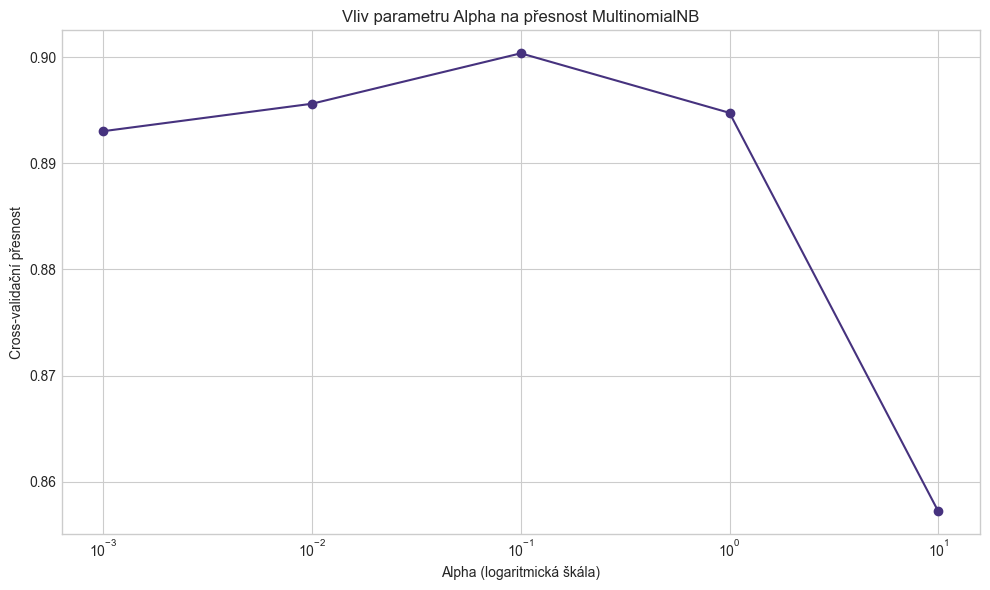

In [13]:
# Vizualizace vlivu alpha parametru na přesnost
alpha_results = []
for params, mean_score, _ in zip(
    grid_search.cv_results_['params'], 
    grid_search.cv_results_['mean_test_score'], 
    grid_search.cv_results_['std_test_score']
):
    if params['vect__min_df'] == grid_search.best_params_['vect__min_df'] and \
       params['vect__ngram_range'] == grid_search.best_params_['vect__ngram_range']:
        alpha_results.append((params['clf__alpha'], mean_score))

alpha_values, scores = zip(*sorted(alpha_results))

plt.figure(figsize=(10, 6))
plt.semilogx(alpha_values, scores, 'o-')
plt.grid(True)
plt.xlabel('Alpha (logaritmická škála)')
plt.ylabel('Cross-validační přesnost')
plt.title('Vliv parametru Alpha na přesnost MultinomialNB')
plt.tight_layout()
plt.show()

## 5. Porovnání CountVectorizer a TfidfVectorizer pro textovou klasifikaci

Pro textovou klasifikaci s Naive Bayes je důležitá volba způsobu reprezentace textu. Porovnáme dva běžné přístupy: CountVectorizer (počty výskytů slov) a TfidfVectorizer (term frequency-inverse document frequency).

In [14]:
# Definice pipelines
pipelines = [
    ('CountVectorizer + MultinomialNB', Pipeline([
        ('vect', CountVectorizer(min_df=5, stop_words='english')),
        ('clf', MultinomialNB(alpha=0.01))
    ])),
    ('TfidfVectorizer + MultinomialNB', Pipeline([
        ('vect', TfidfVectorizer(min_df=5, stop_words='english')),
        ('clf', MultinomialNB(alpha=0.01))
    ])),
    ('CountVectorizer + BernoulliNB', Pipeline([
        ('vect', CountVectorizer(min_df=5, stop_words='english')),
        ('clf', BernoulliNB(alpha=0.01))
    ])),
    ('TfidfVectorizer + BernoulliNB', Pipeline([
        ('vect', TfidfVectorizer(min_df=5, stop_words='english')),
        ('clf', BernoulliNB(alpha=0.01))
    ]))
]

# Vyhodnocení pipelines
vectorizer_results = []

for name, pipeline in pipelines:
    # Trénování
    start_time = time()
    pipeline.fit(news_train.data, news_train.target)
    train_time = time() - start_time
    
    # Predikce
    start_time = time()
    y_pred = pipeline.predict(news_test.data)
    predict_time = time() - start_time
    
    # Metriky
    accuracy = accuracy_score(news_test.target, y_pred)
    
    # Uložení výsledků
    vectorizer_results.append({
        'name': name,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time': predict_time
    })
    
    # Výpis výsledků
    print(f"\n{name}:")
    print(f"Přesnost: {accuracy:.4f}")
    print(f"Čas trénování: {train_time:.4f} s")
    print(f"Čas predikce: {predict_time:.4f} s")

# Vizualizace výsledků
vectorizer_df = pd.DataFrame(vectorizer_results)
print("\nSouhrnné výsledky:")
print(vectorizer_df)


CountVectorizer + MultinomialNB:
Přesnost: 0.8658
Čas trénování: 0.3712 s
Čas predikce: 0.1602 s

TfidfVectorizer + MultinomialNB:
Přesnost: 0.8723
Čas trénování: 0.2650 s
Čas predikce: 0.1700 s

CountVectorizer + BernoulliNB:
Přesnost: 0.8179
Čas trénování: 0.3549 s
Čas predikce: 0.2166 s

TfidfVectorizer + BernoulliNB:
Přesnost: 0.8179
Čas trénování: 0.2591 s
Čas predikce: 0.1658 s

Souhrnné výsledky:
                              name  accuracy  train_time  predict_time
0  CountVectorizer + MultinomialNB  0.865846    0.371225      0.160225
1  TfidfVectorizer + MultinomialNB  0.872327    0.265017      0.170001
2    CountVectorizer + BernoulliNB  0.817887    0.354867      0.216598
3    TfidfVectorizer + BernoulliNB  0.817887    0.259081      0.165790


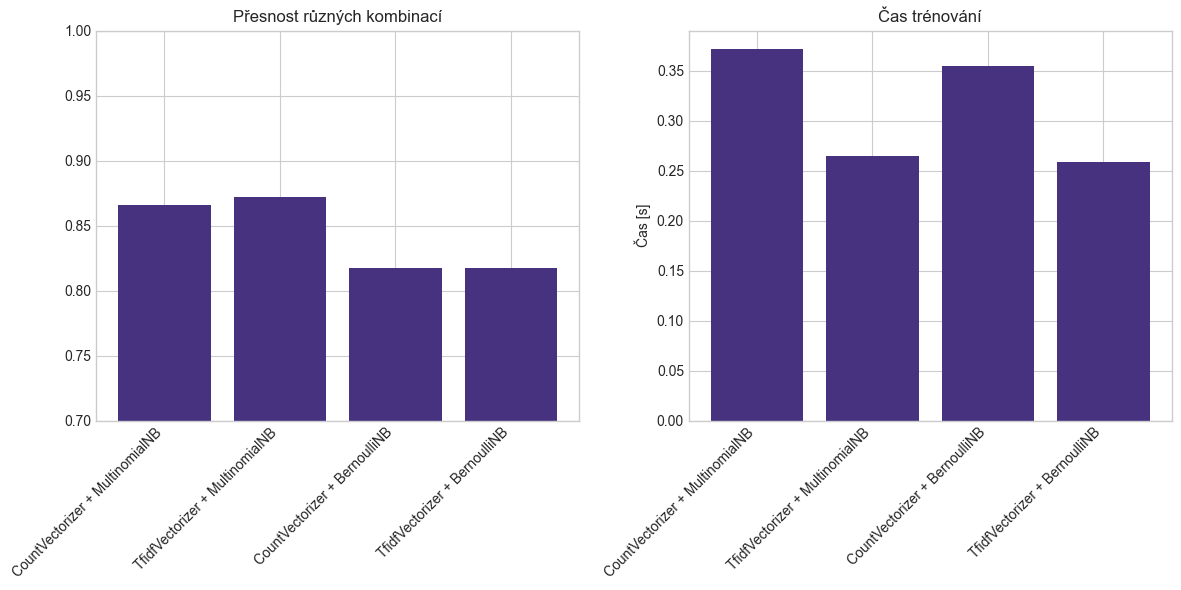

In [15]:
# Vizualizace porovnání
plt.figure(figsize=(12, 6))

# Přesnost
plt.subplot(1, 2, 1)
plt.bar(vectorizer_df['name'], vectorizer_df['accuracy'])
plt.ylim([0.7, 1.0])
plt.title('Přesnost různých kombinací')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')

# Čas trénování
plt.subplot(1, 2, 2)
plt.bar(vectorizer_df['name'], vectorizer_df['train_time'])
plt.title('Čas trénování')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.ylabel('Čas [s]')

plt.tight_layout()
plt.show()

## 6. Praktická ukázka: Filtrování spamu

Jedním z nejčastějších použití Naive Bayes je filtrování spamu. Ukažme si implementaci jednoduchého klasifikátoru spamu s BernoulliNB. Pro ukázku použijeme dataset SMS Spam Collection.

In [16]:
# Stažení datasetu SMS Spam Collection
import urllib.request
import os

# URL datasetu
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
local_filename = "smsspamcollection.zip"

# Stáhnutí dat, pokud ještě nejsou stažena
if not os.path.exists(local_filename):
    print("Stahuji dataset...")
    urllib.request.urlretrieve(url, local_filename)

# Rozbalení ZIP souboru
import zipfile
with zipfile.ZipFile(local_filename, 'r') as zip_ref:
    zip_ref.extractall("sms_data")

# Načtení datasetu
sms_path = "sms_data/SMSSpamCollection"
sms_data = pd.read_csv(sms_path, sep='\t', header=None, names=['label', 'message'])

# Základní informace o datasetu
print(f"Tvar datasetu: {sms_data.shape}")
print(f"Rozložení tříd:\n{sms_data['label'].value_counts()}")
print("\nPříklady zpráv:")
print(sms_data.head())

Tvar datasetu: (5572, 2)
Rozložení tříd:
label
ham     4825
spam     747
Name: count, dtype: int64

Příklady zpráv:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [17]:
# Převod labeled na číselné hodnoty
sms_data['label_num'] = sms_data['label'].map({'ham': 0, 'spam': 1})

# Rozdělení dat na trénovací a testovací množinu
X_train, X_test, y_train, y_test = train_test_split(
    sms_data['message'], sms_data['label_num'], test_size=0.25, random_state=42, stratify=sms_data['label_num']
)

# Vytvoření pipeline pro filtrování spamu
spam_clf = Pipeline([
    ('vect', CountVectorizer(min_df=2, ngram_range=(1, 2), stop_words='english')),
    ('clf', BernoulliNB(alpha=0.1))
])

# Trénování modelu
spam_clf.fit(X_train, y_train)

# Predikce na testovacích datech
y_pred = spam_clf.predict(X_test)

# Metriky
accuracy = accuracy_score(y_test, y_pred)
print(f"Přesnost modelu: {accuracy:.4f}")
print("\nKlasifikační report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Přesnost modelu: 0.9821

Klasifikační report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1206
        spam       1.00      0.87      0.93       187

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393



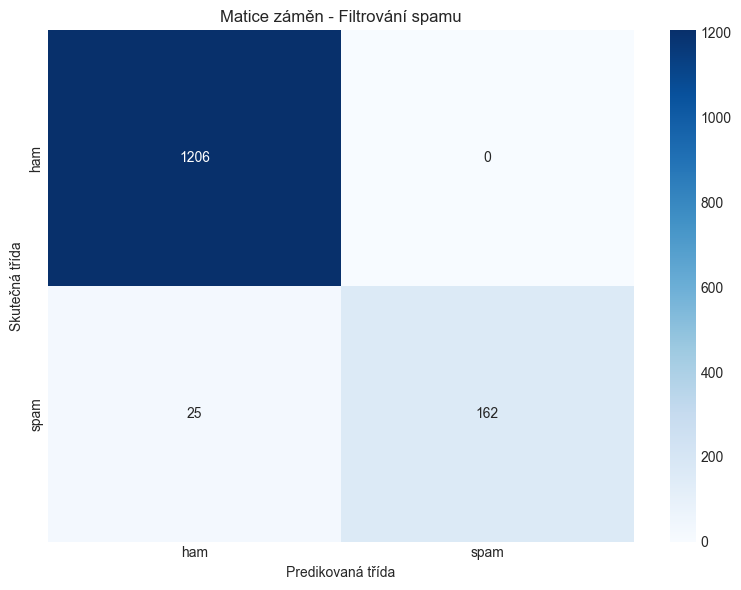

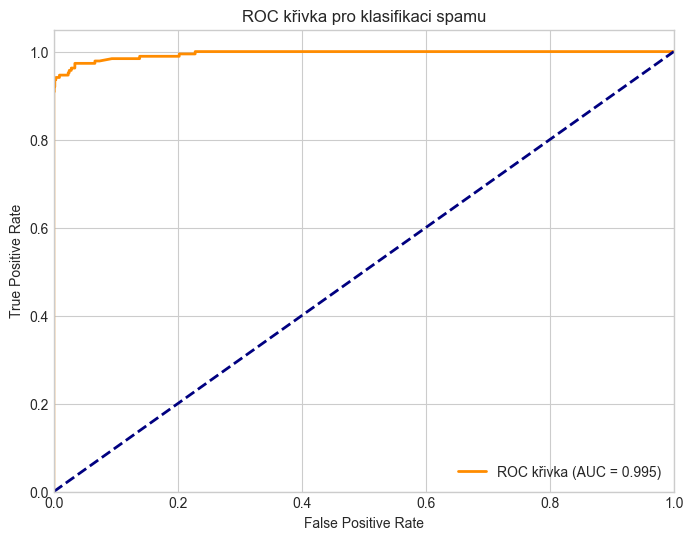

In [18]:
# Matice záměn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predikovaná třída')
plt.ylabel('Skutečná třída')
plt.title('Matice záměn - Filtrování spamu')
plt.tight_layout()
plt.show()

# ROC křivka
y_score = spam_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC křivka (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC křivka pro klasifikaci spamu')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Analýza nejdůležitějších slov pro klasifikaci spamu

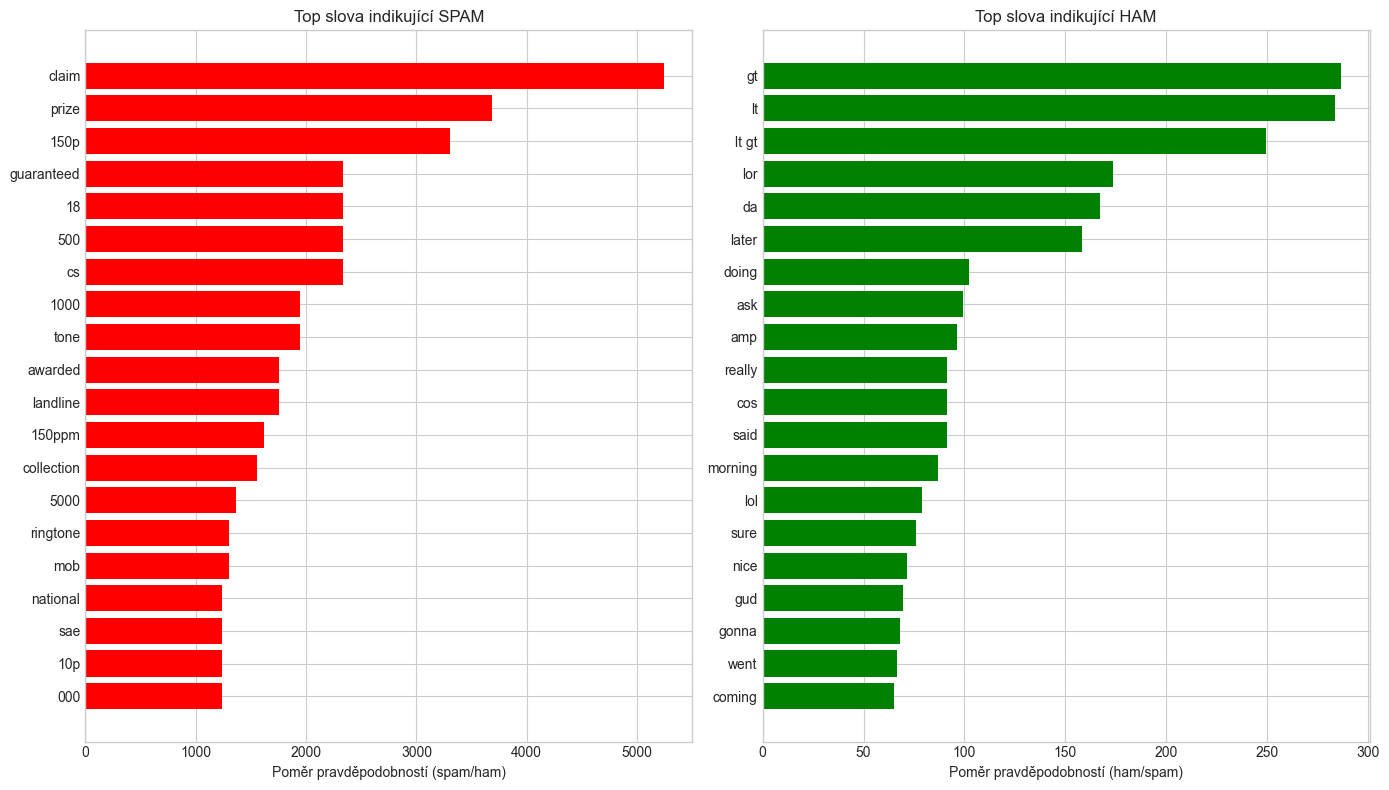

In [19]:
# Získání vektorizéru a klasifikátoru z pipeline
vectorizer = spam_clf.named_steps['vect']
classifier = spam_clf.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

# Log pravděpodobnosti pro spam a ham
log_prob_spam = classifier.feature_log_prob_[1]  # Log pravděpodobnosti pro spam
log_prob_ham = classifier.feature_log_prob_[0]   # Log pravděpodobnosti pro ham

# Výpočet poměru pravděpodobností (likelihood ratio) pro každé slovo
spam_ham_ratio = log_prob_spam - log_prob_ham

# Top N slov charakteristických pro spam a ham
top_n = 20
top_spam_indices = np.argsort(spam_ham_ratio)[::-1][:top_n]
top_ham_indices = np.argsort(spam_ham_ratio)[:top_n]

# Získání slov a jejich poměrů
top_spam_words = [(feature_names[i], np.exp(spam_ham_ratio[i])) for i in top_spam_indices]
top_ham_words = [(feature_names[i], np.exp(spam_ham_ratio[i])) for i in top_ham_indices]

# Vizualizace
plt.figure(figsize=(14, 8))

# Slova charakteristická pro spam
plt.subplot(1, 2, 1)
words, ratios = zip(*top_spam_words)
plt.barh(range(len(words)), ratios, color='red')
plt.yticks(range(len(words)), words)
plt.title('Top slova indikující SPAM')
plt.xlabel('Poměr pravděpodobností (spam/ham)')
plt.gca().invert_yaxis()  # Nejdůležitější nahoře

# Slova charakteristická pro ham
plt.subplot(1, 2, 2)
words, ratios = zip(*top_ham_words)
plt.barh(range(len(words)), [1/r for r in ratios], color='green')  # Převrácení poměru pro lepší vizualizaci
plt.yticks(range(len(words)), words)
plt.title('Top slova indikující HAM')
plt.xlabel('Poměr pravděpodobností (ham/spam)')
plt.gca().invert_yaxis()  # Nejdůležitější nahoře

plt.tight_layout()
plt.show()

## 7. Interaktivní demo: Klasifikátor spamu

Vytvořme jednoduché interaktivní demo, kde můžeme zadávat vlastní SMS zprávy a nechat je klasifikovat naším modelem.

In [20]:
def classify_message(message):
    """Klasifikuje zprávu jako spam nebo ham"""
    # Predikce třídy a pravděpodobnosti
    pred = spam_clf.predict([message])[0]
    proba = spam_clf.predict_proba([message])[0]
    
    # Výsledek
    result = "SPAM" if pred == 1 else "HAM (legitimní zpráva)"
    confidence = proba[1] if pred == 1 else proba[0]
    
    return result, confidence

# Demo s některými testovacími zprávami
test_messages = [
    "Hi honey, what are you doing tonight?",
    "CONGRATULATIONS! You've won a $1,000 Walmart gift card. Go to http://bit.ly/123 to claim now!",
    "Meeting scheduled for tomorrow at 10am, don't forget your presentation",
    "URGENT: Your bank account has been compromised. Call this number immediately: +44 7700 900123",
    "Can you pick up some milk on your way home?"
]

for message in test_messages:
    result, confidence = classify_message(message)
    print(f"\nZpráva: {message}")
    print(f"Klasifikace: {result}")
    print(f"Jistota: {confidence:.4f} ({confidence*100:.1f}%)")


Zpráva: Hi honey, what are you doing tonight?
Klasifikace: HAM (legitimní zpráva)
Jistota: 1.0000 (100.0%)

Zpráva: CONGRATULATIONS! You've won a $1,000 Walmart gift card. Go to http://bit.ly/123 to claim now!
Klasifikace: SPAM
Jistota: 1.0000 (100.0%)

Zpráva: Meeting scheduled for tomorrow at 10am, don't forget your presentation
Klasifikace: HAM (legitimní zpráva)
Jistota: 1.0000 (100.0%)

Zpráva: URGENT: Your bank account has been compromised. Call this number immediately: +44 7700 900123
Klasifikace: HAM (legitimní zpráva)
Jistota: 0.9997 (100.0%)

Zpráva: Can you pick up some milk on your way home?
Klasifikace: HAM (legitimní zpráva)
Jistota: 1.0000 (100.0%)


In [21]:
# Interaktivní vstup (umožňuje zadat vlastní zprávu)
from ipywidgets import widgets, interact

@interact
def interactive_classify(message=widgets.Textarea(value="Enter your message here", layout=widgets.Layout(width='100%', height='80px'))):
    if message:
        result, confidence = classify_message(message)
        print(f"Klasifikace: {result}")
        print(f"Jistota: {confidence:.4f} ({confidence*100:.1f}%)")

interactive(children=(Textarea(value='Enter your message here', description='message', layout=Layout(height='8…

## 8. Závěrečné shrnutí a tipy pro praktické použití

### Shrnutí výhod Naive Bayes:

1. **Rychlost a efektivita**: Naive Bayes je výpočetně velmi efektivní a trénuje se rychle i na velkých datasetech.
2. **Dobrý výkon s malým množstvím dat**: Díky jednoduchosti modelu může dobře generalizovat i s relativně malým počtem trénovacích vzorků.
3. **Interpretovatelnost**: Model poskytuje přímý vhled do důležitosti příznaků pro jednotlivé třídy.
4. **Skvělý pro textová data**: Zejména MultinomialNB a BernoulliNB se prokázaly jako velmi efektivní pro klasifikaci textu.
5. **Odolnost vůči irelevantním příznakům**: Méně důležité příznaky mají typicky menší vliv na konečnou klasifikaci.

### Praktické tipy pro použití Naive Bayes:

1. **Výběr správného typu**:
   - **GaussianNB**: Pro spojité příznaky s přibližně normálním rozdělením
   - **MultinomialNB**: Pro diskrétní počty (např. četnost slov v textu)
   - **BernoulliNB**: Pro binární/boolean příznaky (přítomnost/nepřítomnost)
   - **ComplementNB**: Pro nevyvážené datasety s textem
   - **CategoricalNB**: Pro kategorické příznaky

2. **Optimalizace hyperparametru `alpha`**: 
   - Vyhlazovací parametr alpha je klíčový pro výkon (zejména pro MultinomialNB a BernoulliNB)
   - Použijte GridSearchCV k nalezení optimální hodnoty
   - Typické hodnoty jsou mezi 0.001 a 1.0

3. **Předzpracování pro textová data**:
   - Odstraňte stop slova a interpunkci
   - Zvažte stemming nebo lemmatizaci
   - Experimentujte s TF-IDF vs. počty slov
   - Zkuste kombinace unigramů a bigramů

4. **Řešení problému nulovách frekvencí**:
   - Výchozí Laplaceovo vyhlazování (`alpha > 0`) pomáhá
   - Zvažte přidání malé konstanty ke všem četnostem

5. **Kombinování s jinými technikami**:
   - Použijte Naive Bayes jako základní model v ensemble metodách
   - Můžete ho kombinovat s jinými klasifikátory pomocí stacking nebo voting

6. **Kdy zvážit alternativy**:
   - Když máte silně korelované příznaky
   - Pro velmi komplexní problémy, kde jednoduchý model nemusí stačit
   - Když je prioritou maximální přesnost nad rychlostí nebo interpretovatelností

Naive Bayes zůstává jedním z nejužitečnějších nástrojů ve vaší sadě nástrojů pro strojové učení - je to rychlý, jednoduchý a překvapivě efektivní klasifikátor, který by měl být vždy součástí vašeho procesu modelování, ať už jako základní model nebo jako součást složitějšího řešení.